In [15]:
import torch
import torchaudio
from audio_help_functions import plot_specgram, plot_spectrogram, play_audio, plot_waveform
from audio_preprocessing import standard_frame_rate, max_duration_ms, mfcc_transform, audio_formatting
from torchaudio.utils import download_asset
import scipy.signal
import matplotlib.pyplot as plt
import numpy as np

### Room reverb

In [ ]:
audio = torchaudio.load("./Animal-Soundprepros/Dog/Dog_49.wav")

In [ ]:
SAMPLE_RIR = download_asset("tutorial-assets/Lab41-SRI-VOiCES-rm1-impulse-mc01-stu-clo-8000hz.wav")

In [ ]:
rir_raw, sample_rate = torchaudio.load(SAMPLE_RIR)
plot_waveform(rir_raw, sample_rate, title="Room Impulse Response (raw)")
plot_specgram(rir_raw, sample_rate)
Audio(rir_raw, rate=sample_rate)

In [ ]:
rir = rir_raw[:, int(sample_rate * 1.01) : int(sample_rate * 1.3)]
rir = rir / torch.linalg.vector_norm(rir, ord=2)

In [ ]:
new_audio = torchaudio.functional.fftconvolve(rir, audio[0])

In [ ]:
play_audio(*audio)
play_audio(new_audio, audio[1])

In [ ]:
torchaudio.save("reverb.wav", new_audio, sample_rate)

### Microphone noise

In [2]:
noisy_dog_waveform, sample_rate = torchaudio.load("./dog_mic_recording.wav")

In [3]:
noisy_dog_waveform.size()

torch.Size([1, 40000])

In [4]:
play_audio(noisy_dog_waveform, sample_rate)

In [6]:
real_noise = noisy_dog_waveform[0][3000:8000].unsqueeze(0)

In [7]:
mean = real_noise.mean()
std = real_noise.std()
print(f"Mean: {mean:.5f}, Std: {std:.5f}")

Mean: -0.00385, Std: 0.00478


In [44]:
gaussian_noise = torch.randn(noisy_dog_waveform.size())*mean + std

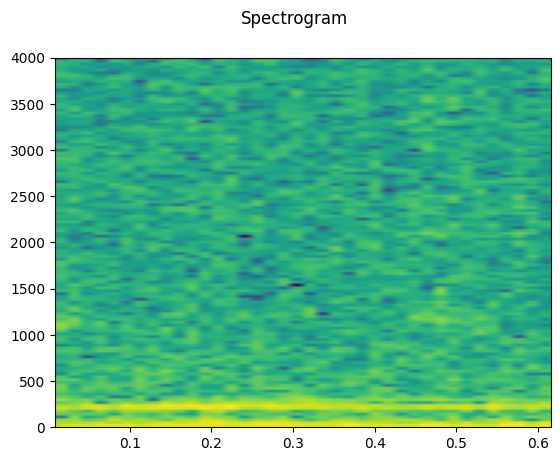

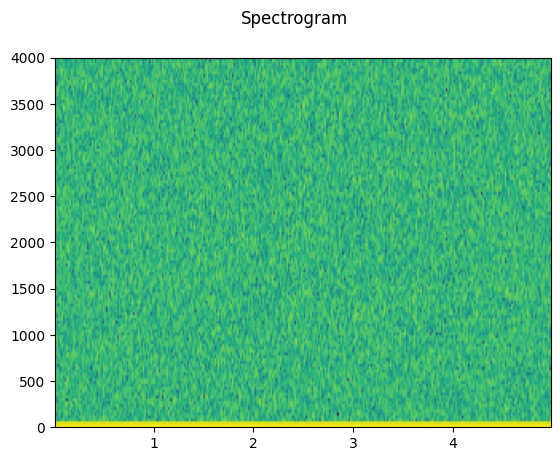

In [47]:
plot_specgram(real_noise, sample_rate)
plot_specgram(gaussian_noise, sample_rate)

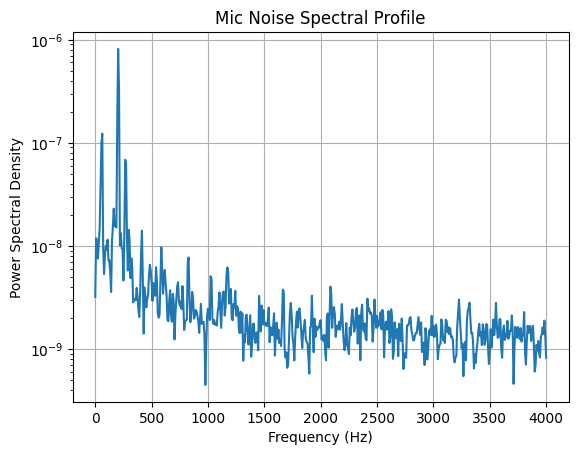

In [48]:
frequencies, psd = scipy.signal.welch(real_noise, fs=sample_rate, nperseg=1024)

plt.semilogy(frequencies, psd[0])
plt.title("Mic Noise Spectral Profile")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.grid(True)
plt.show()

In [49]:
n_frequencies = frequencies / (sample_rate / 2)

magnitude_response = np.sqrt(psd)

num_taps = 1025 
fir_filter = scipy.signal.firwin2(num_taps, n_frequencies, magnitude_response[0])

In [50]:
shaped_noise = torch.tensor(scipy.signal.lfilter(fir_filter, [1.0], gaussian_noise))

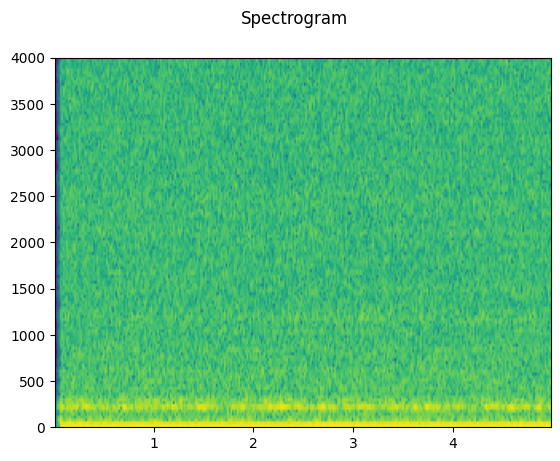

In [51]:
plot_specgram(shaped_noise, sample_rate)

In [60]:
clean_dog = audio_formatting("./test_data/dog1.wav", standard_frame_rate, max_duration_ms)

In [67]:
clean_dog_waveform = clean_dog[0]

In [69]:
play_audio(clean_dog_waveform, sample_rate)

In [53]:
clean_dog[0].size()

torch.Size([1, 32280])

In [58]:
play_audio(real_noise, sample_rate)
play_audio(gaussian_noise, sample_rate)
play_audio(shaped_noise, sample_rate)

In [79]:
fitted_shaped_noise = shaped_noise[0][0:32280].unsqueeze(0)

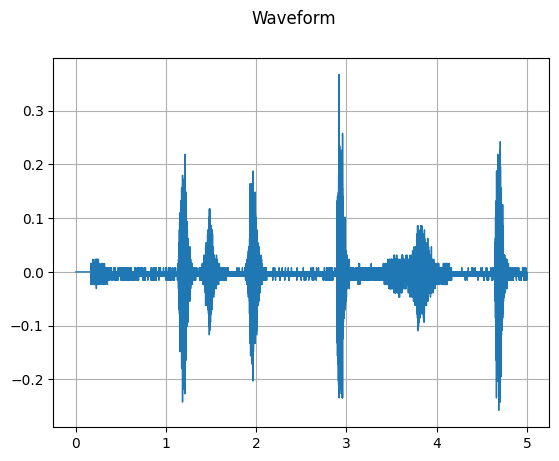

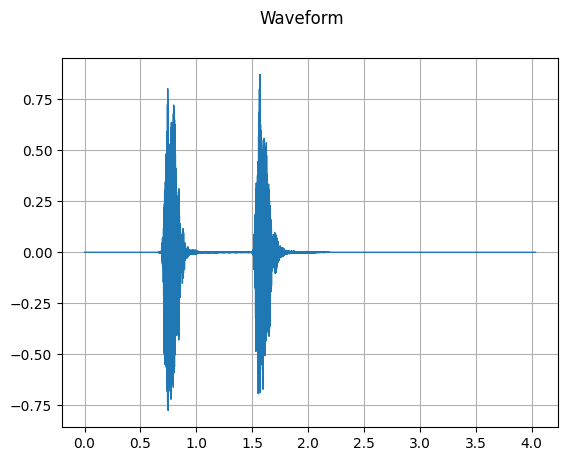

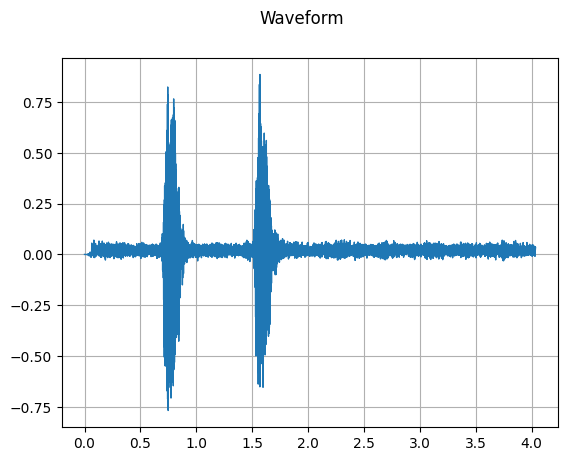

In [95]:
plot_waveform(noisy_dog_waveform, sample_rate)
plot_waveform(clean_dog_waveform, sample_rate)
plot_waveform(clean_dog_waveform + 50000 * fitted_shaped_noise, sample_rate)

In [93]:
play_audio(noisy_dog_waveform, sample_rate)
play_audio(clean_dog_waveform, sample_rate)
play_audio(clean_dog_waveform + 50000 * fitted_shaped_noise, sample_rate)